<a href="https://colab.research.google.com/github/DharmaSwaroop/OS_Project_Repo/blob/main/Phase1_gpu_baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Phase 1: Conventional GPU-Resident Baseline

In this Notebook we are establishing our reference system for evaluating memory-efficient LLM serving. As outlined in our proposal, we are simulating a conventional serving pipeline where the KV cache remains entirely resident on the GPU.

We will measure:
* **Latency:** End-to-end wall-clock time for token generation.
* **Throughput:** Tokens generated per second.
* **GPU Memory Utilization:** Peak VRAM footprint during autoregressive decoding.

These metrics will serve as our baseline to quantify the trade-offs of the hot/cold KV caching policy we implement in Phase 3.

In [2]:
# Install dependencies (only needed once per Colab session)
!pip install -q torch transformers pandas matplotlib seaborn

import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, DynamicCache
import time
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Initialization
model_name = "gpt2"
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Initializing {model_name} on {device}...")

# 2. Load Tokenizer
tokenizer = AutoTokenizer.from_pretrained(model_name)
tokenizer.pad_token = tokenizer.eos_token

# 3. Load Model to GPU
model = AutoModelForCausalLM.from_pretrained(model_name).to(device)
model.eval()

print("Environment and Model are ready!")

Initializing gpt2 on cuda...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

GPT2LMHeadModel LOAD REPORT from: gpt2
Key                  | Status     |  | 
---------------------+------------+--+-
h.{0...11}.attn.bias | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

Environment and Model are ready!


## The Benchmarking Suite (with Total Cache Control)

The following loop tests our system against varying batch sizes and output sequence lengths.

Instead of using `model.generate()`, we explicitly instantiate a `DynamicCache()` object. This allows us to hold the Key and Value matrices in our own variable. While everything stays on the GPU for this Phase 1 baseline, having this object exposed is the architectural hook we need to eventually slice the tensors and move "cold" entries to the CPU in later phases.

In [3]:
def count_tensor_bytes(obj):
    """Recursively walks through any Hugging Face cache structure to sum up tensor bytes."""
    # if the obj is a raw tensor
    if isinstance(obj, torch.Tensor):
        return obj.nelement() * obj.element_size() # number of elements * element size
    # else if the obj is list ot tuple of tensors
    elif isinstance(obj, (tuple, list)):
        return sum(count_tensor_bytes(x) for x in obj)
    # else if the obj has a method called '__iter__'
    elif hasattr(obj, '__iter__'):
        # Safely handle HF's custom iterable Cache objects
        return sum(count_tensor_bytes(x) for x in obj)
    return 0

def run_controlled_benchmark():
    batch_sizes = [1, 4, 8, 16]
    sequence_lengths = [32, 64, 128]
    base_prompt = "This is the begining of a base promt, After this we have"
    results = []

    print("-" * 90)
    print(f"{'Batch Size':<12} | {'Seq Length':<12} | {'Latency (s)':<12} | {'Throughput':<12} | {'Peak VRAM':<12} | {'KV Cache (MB)'}")
    print("-" * 90)

    for batch_size in batch_sizes:
        for seq_len in sequence_lengths:
            prompts = [base_prompt] * batch_size
            inputs = tokenizer(prompts, return_tensors="pt", padding=True).to(device)
            input_ids = inputs.input_ids

            # Reset Memory Trackers
            torch.cuda.empty_cache()
            torch.cuda.reset_peak_memory_stats()

            # --- TOTAL CONTROL OVER THE KV CACHE ---
            my_kv_cache = DynamicCache()

            start_time = time.perf_counter()

            with torch.no_grad():
                # 1. PREFILL PHASE
                outputs = model(
                    input_ids=input_ids,
                    past_key_values=my_kv_cache,
                    use_cache=True
                )

                my_kv_cache = outputs.past_key_values
                next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
                generated_tokens = 1

                # 2. DECODE PHASE
                for _ in range(seq_len - 1):
                    outputs = model(
                        input_ids=next_token,
                        past_key_values=my_kv_cache,
                        use_cache=True
                    )
                    my_kv_cache = outputs.past_key_values
                    next_token = torch.argmax(outputs.logits[:, -1, :], dim=-1).unsqueeze(1)
                    generated_tokens += 1

            end_time = time.perf_counter()

            # Calculate Metrics
            peak_memory_mb = torch.cuda.max_memory_allocated() / (1024 * 1024)

            # Use our custom memory walker to calculate exact KV Cache size
            kv_cache_bytes = count_tensor_bytes(my_kv_cache)
            kv_cache_mb = kv_cache_bytes / (1024 * 1024)

            latency = end_time - start_time
            total_generated_tokens = generated_tokens * batch_size
            throughput = total_generated_tokens / latency

            print(f"{batch_size:<12} | {seq_len:<12} | {latency:<12.4f} | {throughput:<12.2f} | {peak_memory_mb:<12.2f} | {kv_cache_mb:<15.2f}")

            results.append({
                "Batch Size": batch_size,
                "Sequence Length": seq_len,
                "Latency (s)": latency,
                "Throughput (tok/s)": throughput,
                "Peak VRAM (MB)": peak_memory_mb,
                "KV Cache (MB)": kv_cache_mb
            })

            # CRITICAL: Clean up memory before the next loop to avoid negative deltas!
            del inputs, input_ids, outputs, next_token, my_kv_cache

    return pd.DataFrame(results)

df_baseline_results = run_controlled_benchmark()

------------------------------------------------------------------------------------------
Batch Size   | Seq Length   | Latency (s)  | Throughput   | Peak VRAM    | KV Cache (MB)
------------------------------------------------------------------------------------------
1            | 32           | 2.3826       | 13.43        | 501.41       | 3.23           
1            | 64           | 2.3575       | 27.15        | 503.14       | 5.48           
1            | 128          | 4.5156       | 28.35        | 507.82       | 9.98           
4            | 32           | 1.6614       | 77.04        | 514.49       | 12.94          
4            | 64           | 1.7657       | 144.98       | 520.90       | 21.94          
4            | 128          | 1.9499       | 262.57       | 545.47       | 39.94          
8            | 32           | 0.4969       | 515.24       | 545.80       | 25.88          
8            | 64           | 1.0254       | 499.31       | 547.77       | 43.88          
8

## Performance Analysis

The final step is to plot our collected metrics. These graphs will demonstrate the severe GPU overprovisioning caused by keeping the entire KV cache on the hardware[cite: 24, 46].

The left graph (Memory vs. Batch Size) will prove the linear growth of the cache, while the right graph (Throughput vs. Batch Size) will show how performance degrades as VRAM becomes fully saturated.

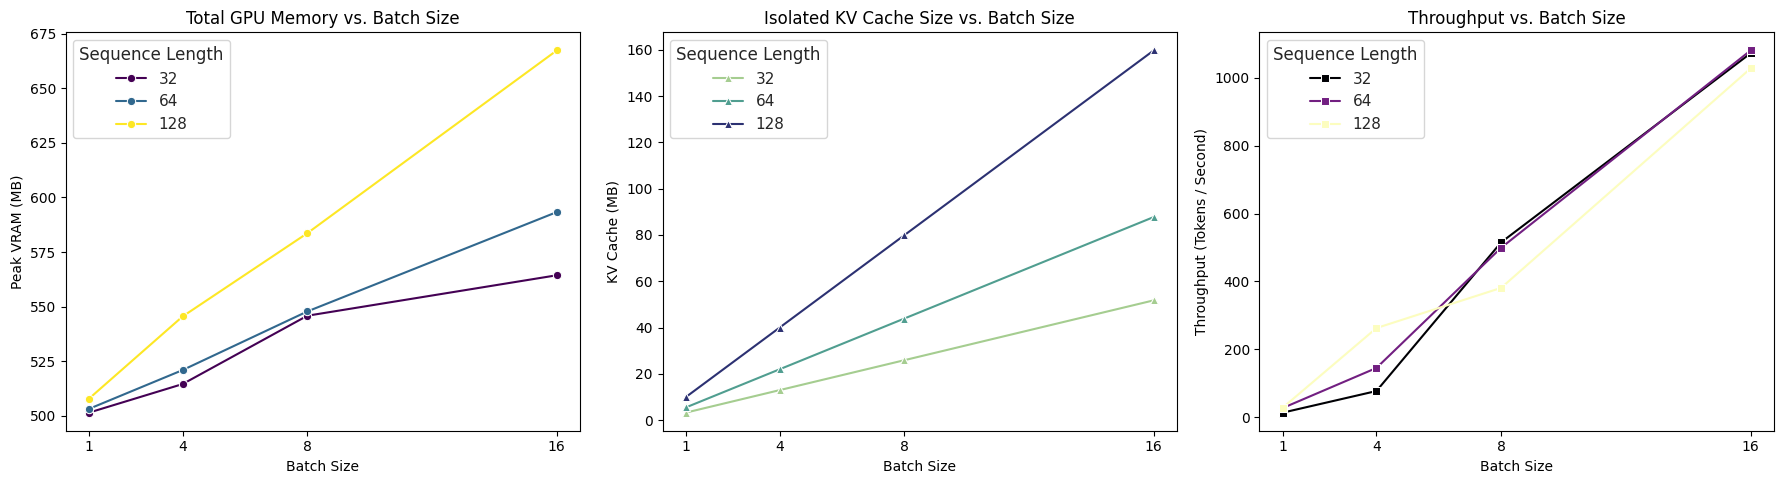

In [4]:
def plot_baseline_results(df):
    # Expanded to 3 subplots to include the isolated KV Cache metric
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    sns.set_theme(style="whitegrid")

    # Plot 1: Total Peak VRAM
    sns.lineplot(
        data=df, x="Batch Size", y="Peak VRAM (MB)", hue="Sequence Length",
        marker="o", palette="viridis", ax=axes[0]
    )
    axes[0].set_title("Total GPU Memory vs. Batch Size")
    axes[0].set_ylabel("Peak VRAM (MB)")
    axes[0].set_xticks(df["Batch Size"].unique())

    # Plot 2: Isolated KV Cache Size
    sns.lineplot(
        data=df, x="Batch Size", y="KV Cache (MB)", hue="Sequence Length",
        marker="^", palette="crest", ax=axes[1]
    )
    axes[1].set_title("Isolated KV Cache Size vs. Batch Size")
    axes[1].set_ylabel("KV Cache (MB)")
    axes[1].set_xticks(df["Batch Size"].unique())

    # Plot 3: Throughput
    sns.lineplot(
        data=df, x="Batch Size", y="Throughput (tok/s)", hue="Sequence Length",
        marker="s", palette="magma", ax=axes[2]
    )
    axes[2].set_title("Throughput vs. Batch Size")
    axes[2].set_ylabel("Throughput (Tokens / Second)")
    axes[2].set_xticks(df["Batch Size"].unique())

    plt.tight_layout()
    plt.show()

plot_baseline_results(df_baseline_results)